<a href="https://colab.research.google.com/github/Farres26/CIS-3902-Data-Mining/blob/main/Mushroom_Reduced_Student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mushroom Decision Tree (Reduced Features) — Student Exercise
## Your Name: Farres Amrhar
## Date: 3/2/26
### In Blackboard you will submit your Github URL after saving your notebook to your class repository, AND a PDF of this notebook (in Colab, File . . . Print . . . PDF)
This activity uses a simplified version of the Mushroom dataset to create a decision tree.

## Goals
- Build a decision tree classifier
- Interpret a confusion matrix and accuracy
- Explain what the root and first-level nodes mean
- Translate tree splits into plain English


## 1️⃣ Setup

In [10]:

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


## 2️⃣ Load the Mushroom dataset (code is completed for you)
**Target:** `class`
- `e` = edible which becomes 0 or not poisonous
- `p` = poisonous which becomes 1

In [11]:

mush = fetch_openml('mushroom', version=1, as_frame=True)
df = mush.frame.copy()

df = df.rename(columns={"bruises%3F": "bruises"})
df.head()


,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat,class
0,x,s,n,t,p,f,c,n,k,e,...,w,w,p,w,o,p,k,s,u,p
1,x,s,y,t,a,f,c,b,k,e,...,w,w,p,w,o,p,n,n,g,e
2,b,s,w,t,l,f,c,b,n,e,...,w,w,p,w,o,p,n,n,m,e
3,x,y,w,t,p,f,c,n,n,e,...,w,w,p,w,o,p,k,s,u,p
4,x,s,g,f,n,f,w,b,k,t,...,w,w,p,w,o,e,n,a,g,e


## 3️⃣ Use a reduced feature set (code is completed for you)
These features are highly predictive and keep the tree readable. Note the class is mapped to 0 (edible) and 1 (poisonous).

In [12]:

features = ['odor', 'spore-print-color', 'gill-size', 'gill-color', 'bruises']

X = df[features]
y = df['class'].map({'e':0, 'p':1})

X.head(), y.value_counts()


(  odor spore-print-color gill-size gill-color bruises
 0    p                 k         n          k       t
 1    a                 n         b          k       t
 2    l                 n         b          n       t
 3    p                 k         n          n       t
 4    n                 n         b          k       f,
 class
 0    4208
 1    3916
 Name: count, dtype: int64)

## 4️⃣ One‑hot encode the categorical features (Add Code)
Each category becomes a YES/NO column.

In [13]:
X = pd.get_dummies(X, prefix_sep=" = ")
X.head()



,odor = a,odor = c,odor = f,odor = l,odor = m,odor = n,odor = p,odor = s,odor = y,spore-print-color = b,...,gill-color = k,gill-color = n,gill-color = o,gill-color = p,gill-color = r,gill-color = u,gill-color = w,gill-color = y,bruises = f,bruises = t
0,False,False,False,False,False,False,True,False,False,False,...,True,False,False,False,False,False,False,False,False,True
1,True,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,True
2,False,False,False,True,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,True
3,False,False,False,False,False,False,True,False,False,False,...,False,True,False,False,False,False,False,False,False,True
4,False,False,False,False,False,True,False,False,False,False,...,True,False,False,False,False,False,False,False,True,False


## 5️⃣ Train/test split (Add Code)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=0.25, random_state=42, stratify=y
)


## 6️⃣ Train a small decision tree (Add Code)

In [15]:

model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=3, random_state=42)

## 7️⃣ Evaluate the model (Add Code)

In [16]:

pred = model.predict(X_test)
print("Accuracy:", round(accuracy_score(y_test, pred), 3))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, pred))
print("\nClassification Report:\n", classification_report(y_test, pred))


Accuracy: 0.959

Confusion Matrix:
 [[1052    0]
 [  83  896]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      1.00      0.96      1052
           1       1.00      0.92      0.96       979

    accuracy                           0.96      2031
   macro avg       0.96      0.96      0.96      2031
weighted avg       0.96      0.96      0.96      2031



## 8️⃣ Visualize the decision tree (Add Code)

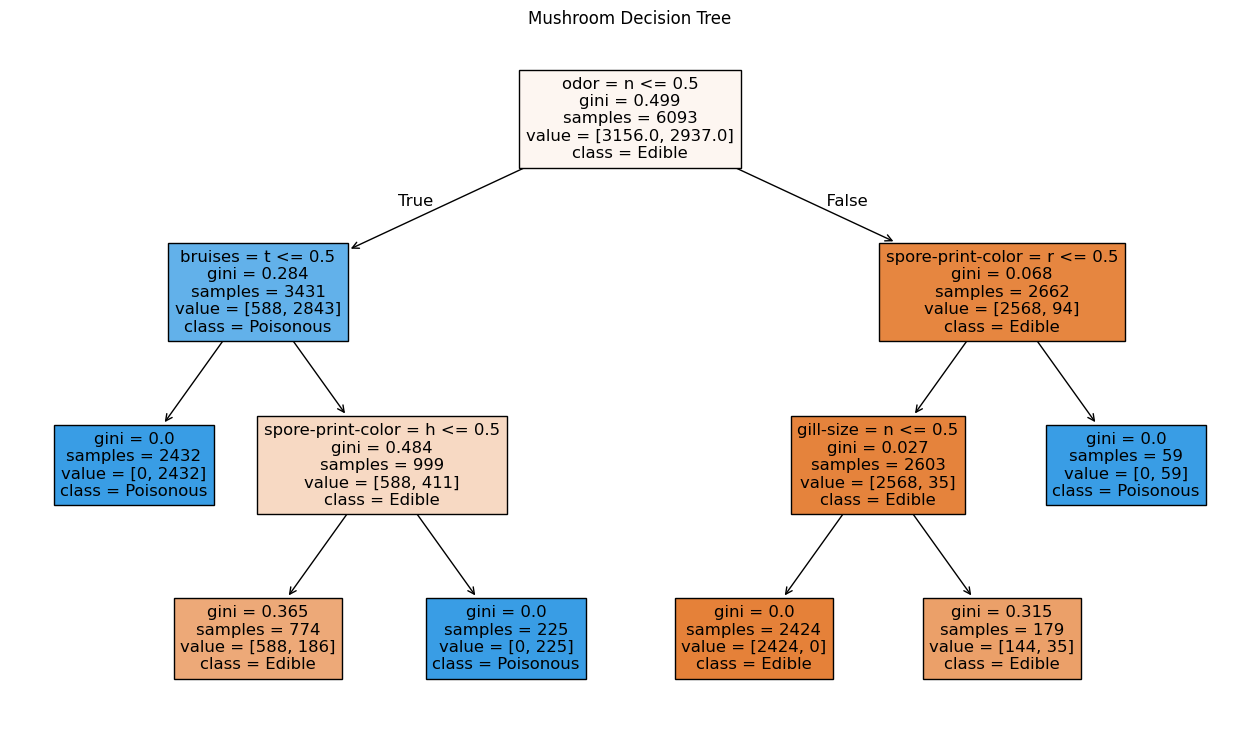

In [17]:
plt.figure(figsize=(16, 9))
plot_tree(model, feature_names=X.columns, class_names=["Edible", "Poisonous"], filled=True)
plt.title("Mushroom Decision Tree")
plt.show()


## 9️⃣ Print IF–THEN rules (Add Code)

In [18]:
from sklearn.tree import export_text

print(export_text(model, feature_names=list(X.columns)))

|--- odor = n <= 0.50
|   |--- bruises = t <= 0.50
|   |   |--- class: 1
|   |--- bruises = t >  0.50
|   |   |--- spore-print-color = h <= 0.50
|   |   |   |--- class: 0
|   |   |--- spore-print-color = h >  0.50
|   |   |   |--- class: 1
|--- odor = n >  0.50
|   |--- spore-print-color = r <= 0.50
|   |   |--- gill-size = n <= 0.50
|   |   |   |--- class: 0
|   |   |--- gill-size = n >  0.50
|   |   |   |--- class: 0
|   |--- spore-print-color = r >  0.50
|   |   |--- class: 1



---
# QUESTIONS TO ANSWER (provide answers in markdown)
### Confusion Matrix & Accuracy
1. What was the model accuracy?

The model had an accuracy of 95.9%

2. How many poisonous mushrooms were correctly classified?

896 poisonous mushrooms

3. How many poisonous mushrooms were incorrectly predicted as edible?

83 poisonous mushrooms were incorrectly predicted

4. Why is misclassifying a poisonous mushroom more serious than misclassifying an edible one?

Misclassifying a poisonous mushroom as edible is more dancourous because false positives can mess up data can cause death or a safety risk.

### Understanding the Tree
5. What feature appears at the **root node**?
 The feature is odor = n

6. What question is the root node asking in plain English?
Does this mushroom have no odor?
7. Describe what the **left branch** and **right branch** mean.
Left branch (<= 0.50): The mushroom does not have "no odor" (meaning it does have a noticeable smell).

Right branch (> 0.50): The mushroom does have "no odor" (meaning it is odorless).

### First Level Nodes
8. Look at the two nodes directly below the root.

   - What feature does each split on?
bruises = t
   - What question is each node asking?
Does the mushroom have bruises?

   - What does following the left vs right branch mean?
Following the left branch (<= 0.50) means False: The mushroom does not have bruises.

Following the right branch (> 0.50) means True: The mushroom does have bruises.

### Interpretation
9. Choose ONE full path from the root to a leaf and translate it into plain English.

Path: odor = n <= 0.50 -> bruises = t <= 0.50 -> class: 1

If the mushroom has a noticeable odor and it does not have bruises, then it is poisonous.

10. Based on the tree, what feature seems most important for predicting if a mushroom is poisonous?

Odor since it was chosen as the root node.

### Exploration
11. Change `max_depth` to 2. What changed?

The tree will become shorter/shallower. It will stop splitting after the first-level nodes. The IF-THEN rules will be much simpler. Accuracy will drop though.

12. Change `max_depth` to 5. What changed?

The tree will grow deeper and much more complex. The oppisite of the other.